IMPORTING LIBRARIES


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

LOADING DATA


In [3]:
train= 'C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Brain-Tumor-Classification/Datasets/Train'
test= 'C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Brain-Tumor-Classification/Datasets/Test'

In [4]:
import os
class_counts= {}
for class_name in os.listdir(train):
    class_path= os.path.join(train, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name]= len(os.listdir(class_path))

print("Class Distribution in the Training Set: ")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}images")

Class Distribution in the Training Set: 
glioma_tumor: 826images
meningioma_tumor: 822images
no_tumor: 395images
pituitary_tumor: 827images


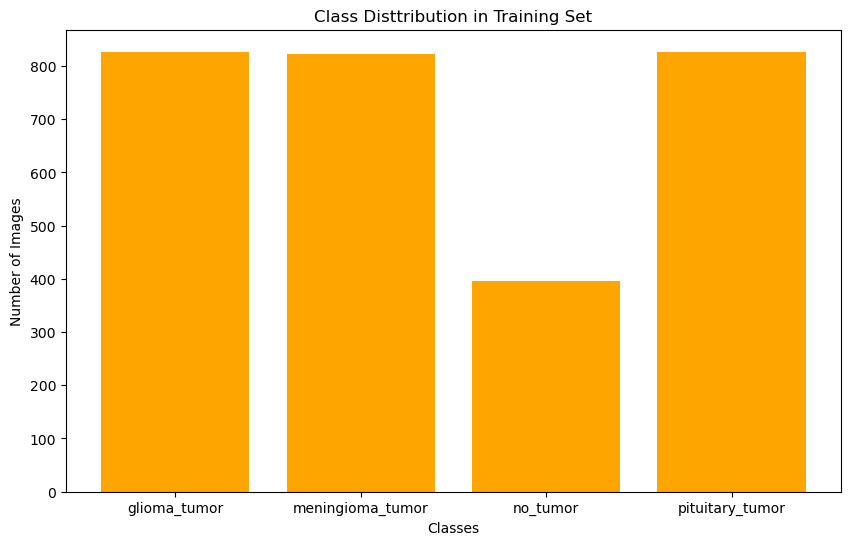

In [5]:
import matplotlib.pyplot as plt
classes= list(class_counts.keys())
counts= list(class_counts.values())

plt.figure(figsize=(10,6))
plt.bar(classes, counts, color='orange')
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Disttribution in Training Set")
plt.show()

In [6]:
# Initializing the ImageDataGenerator with augmentation for training
train_datagen= ImageDataGenerator(rescale=1./255, rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')

# No augmentation for testing, only rescalling
test_datagen= ImageDataGenerator(rescale=1./255)

# Load images and apply transformations
train_generator= train_datagen.flow_from_directory(train, target_size=(150, 150), batch_size=32, class_mode='categorical')

test_generator= test_datagen.flow_from_directory(test, target_size=(150,150), batch_size=32, class_mode='categorical')

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Corrected compile method
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up ImageDataGenerator for training and testing
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Specify directories and target image size
train_generator = train_datagen.flow_from_directory(
    'C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Brain-Tumor-Classification/Datasets/Train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Brain-Tumor-Classification/Datasets/Test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [14]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator
#     callbacks=[early_stopping]
)

Epoch 1/20


c:\Users\samar\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 301ms/step - accuracy: 0.4649 - loss: 1.2631 - val_accuracy: 0.3655 - val_loss: 2.2846
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 326ms/step - accuracy: 0.6787 - loss: 0.7332 - val_accuracy: 0.4619 - val_loss: 1.9336
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 318ms/step - accuracy: 0.7772 - loss: 0.5423 - val_accuracy: 0.5254 - val_loss: 2.2742
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 326ms/step - accuracy: 0.8101 - loss: 0.4355 - val_accuracy: 0.6015 - val_loss: 2.2752
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 330ms/step - accuracy: 0.8788 - loss: 0.3013 - val_accuracy: 0.6193 - val_loss: 2.4186
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 342ms/step - accuracy: 0.8985 - loss: 0.2508 - val_accuracy: 0.6447 - val_loss: 2.5274
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 33s 354ms/step - accuracy: 0.9256 - loss: 0.1874 - val_accuracy: 0.6904 - val_loss: 2.9404
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 33s 360ms/step - accuracy: 0.9468 - loss: 0.1625 - val_accuracy: 0.670

In [15]:
test_loss, test_accuracy= model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.7137 - loss: 4.2391
Test Accuracy: 0.73


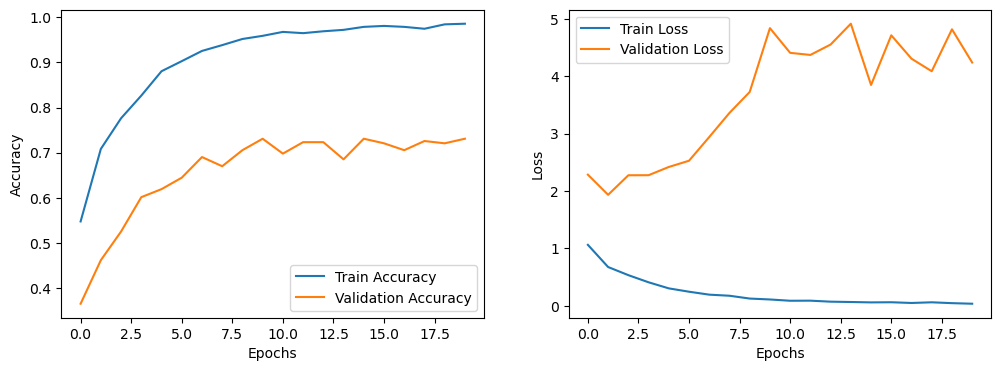

In [18]:
plt.figure(figsize=(12,4))

# Plot Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [20]:
model.save("brain_tumor_classifier.keras")